# 07 - Evaluation: WER/CER Metrics

**Goal**: Quantitative evaluation of Stage 1 and Stage 2 models on the full test set
using Word Error Rate (WER) and Character Error Rate (CER).

**What this notebook does**:
- Load trained models from HuggingFace
- Run inference on the full test set (~8,087 samples)
- Compute corpus-level WER and CER using `jiwer`
- Compare Stage 1 vs Stage 2 quantitatively
- Analyze errors by duration bucket
- Support custom `.wav` file inference
- Save predictions to JSONL for later analysis

**Runtime**: ~2.25 hours per model on a single GPU (~1s/sample).
Use `N_SAMPLES` for quicker runs.

## 1. Environment Setup

In [1]:
# Change to project root so all relative paths (./data, ./checkpoints) work correctly.
import os
os.chdir(os.path.join(os.path.dirname(os.path.abspath(__file__)), "..")
         if "__file__" in dir()
         else os.path.join(os.getcwd(), "..") if os.path.basename(os.getcwd()) == "notebooks"
         else os.getcwd())
print(f"Working directory: {os.getcwd()}")

# Dataset cache must be set BEFORE importing datasets library.
os.environ["HF_DATASETS_CACHE"] = os.path.abspath("./data")

import subprocess
import torch
import gc
import time
import json
import re
import math
from datetime import datetime
from datasets import load_dataset, Audio
from transformers import Qwen2VLForConditionalGeneration, Qwen2VLProcessor
from peft import PeftModel
from qwen_vl_utils import process_vision_info
from jiwer import wer, cer
from tqdm import tqdm
import transformers

# ---------------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------------
N_SAMPLES = None       # None = full test set (~8,087), or 100/1000 for quicker runs
SAVE_PREDICTIONS = True

# ---------------------------------------------------------------------------
# Auto-select the GPU with the most free memory
# ---------------------------------------------------------------------------
def get_free_gpu():
    """Return the GPU index with the most free memory."""
    result = subprocess.run(
        ["nvidia-smi", "--query-gpu=index,memory.used,memory.free",
         "--format=csv,noheader,nounits"],
        capture_output=True, text=True,
    )
    gpus = []
    for line in result.stdout.strip().split("\n"):
        idx, used, free = [int(x.strip()) for x in line.split(",")]
        gpus.append((idx, used, free))

    available = [(idx, free) for idx, used, free in gpus if used < 500]
    if not available:
        available = [(idx, free) for idx, _, free in gpus]
    best_idx, best_free = max(available, key=lambda x: x[1])

    idle_ids = [str(idx) for idx, used, _ in gpus if used < 500]
    print(f"Available (idle) GPUs: [{', '.join(idle_ids) if idle_ids else 'none'}]")
    return best_idx

GPU_ID = get_free_gpu()
os.environ["CUDA_VISIBLE_DEVICES"] = str(GPU_ID)
DEVICE = "cuda:0"

props = torch.cuda.get_device_properties(0)
print(f"Using GPU {GPU_ID}: {props.name} ({props.total_memory / 1024**3:.1f} GB)")
print(f"Dataset cache:   {os.environ['HF_DATASETS_CACHE']}")

print(f"\ntransformers: {transformers.__version__} ({transformers.__file__})")
print(f"torch: {torch.__version__}")

# HuggingFace login
from huggingface_hub import get_token
HF_TOKEN = get_token()
if HF_TOKEN:
    os.environ["HF_TOKEN"] = HF_TOKEN
    print("HF token loaded.")
else:
    HF_TOKEN = os.environ.get("HF_TOKEN")
    if HF_TOKEN:
        print("HF token loaded from environment.")
    else:
        print("No HF token found. Set HF_TOKEN or run `huggingface-cli login`.")

Working directory: /home/zhuoyuan/projects/speechQwen2VL


/home/zhuoyuan/projects/speechQwen2VL/forks/transformers/src/transformers/utils/hub.py:111: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


Available (idle) GPUs: [2, 3, 6, 7]
Using GPU 2: NVIDIA RTX 6000 Ada Generation (47.5 GB)
Dataset cache:   /home/zhuoyuan/projects/speechQwen2VL/data

transformers: 4.56.0.dev0 (/home/zhuoyuan/projects/speechQwen2VL/forks/transformers/src/transformers/__init__.py)
torch: 2.4.1+cu121
HF token loaded.


## 2. Load Full Test Dataset

Load **all 6 test shards** (~8,087 samples), not just the 100-sample subset
used during training. Optionally subset with `N_SAMPLES` for quicker runs.

In [2]:
test_dataset = load_dataset(
    "speechbrain/LargeScaleASR",
    data_files=["test/test-*"],  # all 6 shards
    num_proc=12,
)
test_dataset = test_dataset["train"]
test_dataset = test_dataset.cast_column("wav", Audio(decode=False))

print(f"Full test set: {len(test_dataset)} samples")
print(f"Columns:       {test_dataset.column_names}")

# Duration statistics
durations = [s["duration"] for s in test_dataset]
print(f"Duration: min={min(durations):.1f}s, max={max(durations):.1f}s, "
      f"mean={sum(durations)/len(durations):.1f}s")

# Deterministic shuffle + optional subset (so smaller N_SAMPLES is representative)
test_dataset = test_dataset.shuffle(seed=42)
if N_SAMPLES is not None:
    test_dataset = test_dataset.select(range(min(N_SAMPLES, len(test_dataset))))
    print(f"Subsetted to {len(test_dataset)} samples")

Full test set: 8087 samples
Columns:       ['ID', 'duration', 'wav', 'spk_id', 'sex', 'text']
Duration: min=1.0s, max=39.7s, mean=7.4s


## 3. Load Stage 2 Model (LoRA)

Load the base model with trained audio projector, then apply LoRA adapters.

In [3]:
STAGE1_REPO = "DanJZY/Qwen2-VL-7B-Speech"
LORA_REPO = "DanJZY/Qwen2-VL-7B-Speech-LoRA"

base_model = Qwen2VLForConditionalGeneration.from_pretrained(
    STAGE1_REPO,
    torch_dtype=torch.bfloat16,
    device_map=DEVICE,
)
base_model.config.use_cache = True  # enable KV cache for faster generation
model = PeftModel.from_pretrained(base_model, LORA_REPO)
model.eval()
processor = Qwen2VLProcessor.from_pretrained(STAGE1_REPO)

print(f"Stage 2 model loaded. GPU memory: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")

# Sanity check: single-sample inference
sample = test_dataset[0]
messages = [
    {"role": "user", "content": [
        {"type": "audio", "audio": sample["wav"]["bytes"]},
        {"type": "text", "text": "Transcribe this audio."},
    ]},
]
image_inputs, video_inputs, audio_inputs = process_vision_info(messages)
text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
batch = processor(text=[text], audios=audio_inputs, return_tensors="pt", padding=True)
batch = {k: v.to(model.device) if isinstance(v, torch.Tensor) else v for k, v in batch.items()}
with torch.inference_mode():
    output_ids = model.generate(**batch, max_new_tokens=256, num_beams=1, do_sample=False)
prompt_len = batch["input_ids"].shape[1]
pred = processor.batch_decode(output_ids[:, prompt_len:], skip_special_tokens=True)[0]
print(f"Sanity check — prediction: {pred}")
print(f"Sanity check — reference:  {sample['text']}")

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Stage 2 model loaded. GPU memory: 17.30 GB
Sanity check — prediction: HE IS AN ACTIVE CHRISTIAN
Sanity check — reference:  HE IS AN ACTIVE CHRISTIAN


## 4. Helper Functions

In [4]:
def run_inference(model, processor, messages, max_new_tokens=256):
    """Run inference on a single conversation."""
    image_inputs, video_inputs, audio_inputs = process_vision_info(messages)
    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    batch = processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        audios=audio_inputs,
        return_tensors="pt",
        padding=True,
    )
    batch = {k: v.to(model.device) if isinstance(v, torch.Tensor) else v for k, v in batch.items()}
    model.eval()
    with torch.inference_mode():
        output_ids = model.generate(
            **batch,
            max_new_tokens=max_new_tokens,
            num_beams=1,
            do_sample=False,
        )
    prompt_len = batch["input_ids"].shape[1]
    generated_ids = output_ids[:, prompt_len:]
    return processor.batch_decode(generated_ids, skip_special_tokens=True)[0]


# ASR-standard normalization: uppercase, strip whitespace, remove punctuation.
# ~15% of test transcripts contain punctuation/apostrophes — removing them
# prevents punctuation differences from inflating WER/CER.
_PUNCT_RE = re.compile(r"[^\w\s]", re.UNICODE)

def normalize_text(text):
    """Normalize text for WER/CER: uppercase, strip, remove punctuation."""
    text = text.upper().strip()
    text = _PUNCT_RE.sub("", text)
    # Collapse multiple spaces into one
    text = re.sub(r"\s+", " ", text).strip()
    return text


def evaluate_model(model, processor, dataset, model_name, max_new_tokens=256):
    """Run inference on dataset, compute WER/CER, return summary and per-sample results."""
    predictions = []
    references = []
    results = []

    for i in tqdm(range(len(dataset)), desc=f"Evaluating {model_name}"):
        sample = dataset[i]
        messages = [
            {"role": "user", "content": [
                {"type": "audio", "audio": sample["wav"]["bytes"]},
                {"type": "text", "text": "Transcribe this audio."},
            ]},
        ]

        pred = run_inference(model, processor, messages, max_new_tokens=max_new_tokens)
        ref = sample["text"]

        pred_norm = normalize_text(pred)
        ref_norm = normalize_text(ref)

        predictions.append(pred_norm)
        references.append(ref_norm)

        # Per-sample metrics
        sample_wer = wer(ref_norm, pred_norm) if ref_norm else float("inf")
        sample_cer = cer(ref_norm, pred_norm) if ref_norm else float("inf")

        results.append({
            "index": i,
            "id": sample.get("ID", ""),
            "duration": sample.get("duration", 0),
            "spk_id": sample.get("spk_id", ""),
            "sex": sample.get("sex", ""),
            "reference_raw": ref,
            "prediction_raw": pred,
            "reference": ref_norm,
            "prediction": pred_norm,
            "wer": sample_wer,
            "cer": sample_cer,
        })

    # Corpus-level metrics (standard ASR: total errors / total reference words)
    corpus_wer = wer(references, predictions)
    corpus_cer = cer(references, predictions)

    summary = {
        "model_name": model_name,
        "n_samples": len(dataset),
        "corpus_wer": corpus_wer,
        "corpus_cer": corpus_cer,
        "timestamp": datetime.now().isoformat(),
    }

    return summary, results


print("Helper functions defined: run_inference(), normalize_text(), evaluate_model()")

Helper functions defined: run_inference(), normalize_text(), evaluate_model()


## 5. Run Evaluation — Choose One Option

**Option A (single GPU)**: Run Sections 5A and 6A below. Evaluates Stage 2 then
Stage 1 sequentially on one GPU. Takes ~4.5 hours for the full test set.

**Option B (multi-GPU, faster)**: Skip 5A/6A entirely. Instead, run the CLI script
in two terminals on separate GPUs:
```bash
# Terminal 1
python scripts/evaluate.py --model stage2 --gpu 0
# Terminal 2
python scripts/evaluate.py --model stage1 --gpu 1
```
Then run Section 5B to load the saved JSONL results for analysis.
This takes ~2.25 hours total (both models in parallel).

### 5A. Evaluate Stage 2 Model (Option A — run in notebook)

In [5]:
# Option A: Run inference in the notebook. Comment out this cell if using Option B.
summary_s2, results_s2 = evaluate_model(
    model, processor, test_dataset, model_name="stage2_lora"
)

print(f"\n=== Stage 2 (LoRA) Results ===")
print(f"Samples: {summary_s2['n_samples']}")
print(f"WER:     {summary_s2['corpus_wer']:.4f} ({summary_s2['corpus_wer']*100:.2f}%)")
print(f"CER:     {summary_s2['corpus_cer']:.4f} ({summary_s2['corpus_cer']*100:.2f}%)")

if SAVE_PREDICTIONS:
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    results_path = f"./checkpoints/eval_stage2_lora_{timestamp}_notebook.jsonl"
    with open(results_path, "w") as f:
        for r in results_s2:
            f.write(json.dumps(r) + "\n")
    summary_path = f"./checkpoints/eval_stage2_lora_{timestamp}_notebook_summary.json"
    with open(summary_path, "w") as f:
        json.dump(summary_s2, f, indent=2)
    print(f"\nResults saved to {results_path}")
    print(f"Summary saved to {summary_path}")

Evaluating stage2_lora: 100%|██████████| 8087/8087 [2:32:43<00:00,  1.13s/it]  



=== Stage 2 (LoRA) Results ===
Samples: 8087
WER:     0.0867 (8.67%)
CER:     0.0475 (4.75%)

Results saved to ./checkpoints/eval_stage2_lora_20260307_181030_notebook.jsonl
Summary saved to ./checkpoints/eval_stage2_lora_20260307_181030_notebook_summary.json


### 6A. Evaluate Stage 1 Model (Option A — run in notebook)

In [6]:
# Option A: Run inference in the notebook. Comment out this cell if using Option B.
# Free Stage 2 model
del model, base_model
gc.collect()
torch.cuda.empty_cache()
time.sleep(2)
print(f"GPU memory after cleanup: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")

# Load Stage 1 model (projector only, no LoRA)
model_s1 = Qwen2VLForConditionalGeneration.from_pretrained(
    STAGE1_REPO,
    torch_dtype=torch.bfloat16,
    device_map=DEVICE,
)
model_s1.config.use_cache = True
model_s1.eval()
print(f"Stage 1 model loaded. GPU memory: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")

GPU memory after cleanup: 0.01 GB


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Stage 1 model loaded. GPU memory: 16.67 GB


In [7]:
# Option A continued.
summary_s1, results_s1 = evaluate_model(
    model_s1, processor, test_dataset, model_name="stage1_projector"
)

print(f"\n=== Stage 1 (Projector Only) Results ===")
print(f"Samples: {summary_s1['n_samples']}")
print(f"WER:     {summary_s1['corpus_wer']:.4f} ({summary_s1['corpus_wer']*100:.2f}%)")
print(f"CER:     {summary_s1['corpus_cer']:.4f} ({summary_s1['corpus_cer']*100:.2f}%)")

if SAVE_PREDICTIONS:
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    results_path = f"./checkpoints/eval_stage1_projector_{timestamp}_notebook.jsonl"
    with open(results_path, "w") as f:
        for r in results_s1:
            f.write(json.dumps(r) + "\n")
    summary_path = f"./checkpoints/eval_stage1_projector_{timestamp}_notebook_summary.json"
    with open(summary_path, "w") as f:
        json.dump(summary_s1, f, indent=2)
    print(f"\nResults saved to {results_path}")
    print(f"Summary saved to {summary_path}")

Evaluating stage1_projector: 100%|██████████| 8087/8087 [1:23:01<00:00,  1.62it/s]



=== Stage 1 (Projector Only) Results ===
Samples: 8087
WER:     0.1289 (12.89%)
CER:     0.0743 (7.43%)

Results saved to ./checkpoints/eval_stage1_projector_20260307_193340_notebook.jsonl
Summary saved to ./checkpoints/eval_stage1_projector_20260307_193340_notebook_summary.json


### 5B. Load Results from CLI (Option B — skip 5A/6A)

If you ran the CLI script, set the paths to the JSONL files below and run this cell.
The summary files end with `_summary.json` and the per-sample files end with `.jsonl`.

In [8]:
# Option B: Load pre-computed results from CLI. Uncomment and set paths.
# import glob
#
# # Auto-find the latest results for each model
# s2_files = sorted(glob.glob("./checkpoints/eval_stage2_lora_*_cli.jsonl"))
# s1_files = sorted(glob.glob("./checkpoints/eval_stage1_projector_*_cli.jsonl"))
#
# if s2_files and s1_files:
#     # Load Stage 2 results
#     results_s2 = []
#     with open(s2_files[-1]) as f:
#         for line in f:
#             results_s2.append(json.loads(line))
#     with open(s2_files[-1].replace("_cli.jsonl", "_cli_summary.json")) as f:
#         summary_s2 = json.load(f)
#
#     # Load Stage 1 results
#     results_s1 = []
#     with open(s1_files[-1]) as f:
#         for line in f:
#             results_s1.append(json.loads(line))
#     with open(s1_files[-1].replace("_cli.jsonl", "_cli_summary.json")) as f:
#         summary_s1 = json.load(f)
#
#     print(f"Loaded Stage 2 results from: {s2_files[-1]} ({len(results_s2)} samples)")
#     print(f"Loaded Stage 1 results from: {s1_files[-1]} ({len(results_s1)} samples)")
#
#     # Sanity check: both runs should have the same number of samples
#     if summary_s1["n_samples"] != summary_s2["n_samples"]:
#         print(f"WARNING: sample count mismatch! Stage 1={summary_s1['n_samples']}, "
#               f"Stage 2={summary_s2['n_samples']}. Comparison may be misleading.")
#
#     print(f"Stage 2 WER: {summary_s2['corpus_wer']:.4f} ({summary_s2['corpus_wer']*100:.2f}%)")
#     print(f"Stage 1 WER: {summary_s1['corpus_wer']:.4f} ({summary_s1['corpus_wer']*100:.2f}%)")
# else:
#     print("No CLI results found. Run the CLI script first or use Option A.")

## 7. Comparison Table + Analysis

In [9]:
print(f"\n{'='*56}")
print(f"{'Metric':<12} {'Stage 1':>12} {'Stage 2':>12} {'Improvement':>16}")
print(f"{'-'*56}")

wer_improve = (summary_s1["corpus_wer"] - summary_s2["corpus_wer"]) / summary_s1["corpus_wer"] * 100 if summary_s1["corpus_wer"] > 0 else 0.0
cer_improve = (summary_s1["corpus_cer"] - summary_s2["corpus_cer"]) / summary_s1["corpus_cer"] * 100 if summary_s1["corpus_cer"] > 0 else 0.0

print(f"{'WER':<12} {summary_s1['corpus_wer']:>11.2%} {summary_s2['corpus_wer']:>11.2%} {wer_improve:>+15.1f}%")
print(f"{'CER':<12} {summary_s1['corpus_cer']:>11.2%} {summary_s2['corpus_cer']:>11.2%} {cer_improve:>+15.1f}%")
print(f"{'='*56}")


Metric            Stage 1      Stage 2      Improvement
--------------------------------------------------------
WER               12.89%       8.67%           +32.7%
CER                7.43%       4.75%           +36.1%


In [16]:
# Worst 10 predictions from Stage 2 (highest WER)
sorted_results = sorted(results_s2, key=lambda x: x["wer"], reverse=True)
print("\n=== Top 10 Worst Predictions (Stage 2) ===\n")
for r in sorted_results[:10]:
    print(f"Sample {r['index']} (WER={r['wer']:.2%}, duration={r['duration']:.1f}s)")
    print(f"  REF: {r.get('reference_raw', r['reference'])}")
    print(f"  HYP: {r.get('prediction_raw', r['prediction'])}")
    print()


=== Top 10 Worst Predictions (Stage 2) ===

Sample 414 (WER=713.33%, duration=21.4s)
  REF: LIFE BEFORE DEATH STRENGTH BEFORE WEAKNESS READING BEFORE FINDING OUT HI JJ HI JJ HI JJ YOU KNOW ITS VERY COOL JJ THANK YOU FOR SHOWING ME THERE'S MY CHILD
  HYP: LIFE BEFORE DEATH STRENGTH BEFORE WEAKNESS READING BEFORE FINDING OUT HI JAY JAY HI JAY JAY HI JAY JAY IT WAS VERY COOL JAY JAY THANK YOU FOR SHOWING ME THERE'S MY CHILD AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH A

In [17]:
# Extract worst-performing samples as .wav files for manual inspection   
# the code saves 10 .wav files to ./checkpoints/worst_samples/ — one per worst prediction. You can play them in any audio player.                                         
import os                                                                                                       
worst_dir = "./checkpoints/worst_samples"
os.makedirs(worst_dir, exist_ok=True)

worst_indices = [r["index"] for r in sorted_results[:10]]
for idx in worst_indices:
    sample = test_dataset[idx]
    audio_bytes = sample["wav"]["bytes"]
    r = sorted_results[worst_indices.index(idx)]
    filename = f"sample_{idx}_wer{r['wer']:.0%}.wav".replace("%", "pct")
    filepath = os.path.join(worst_dir, filename)
    with open(filepath, "wb") as f:
        f.write(audio_bytes)

print(f"Saved {len(worst_indices)} audio files to {worst_dir}/")

Saved 10 audio files to ./checkpoints/worst_samples/


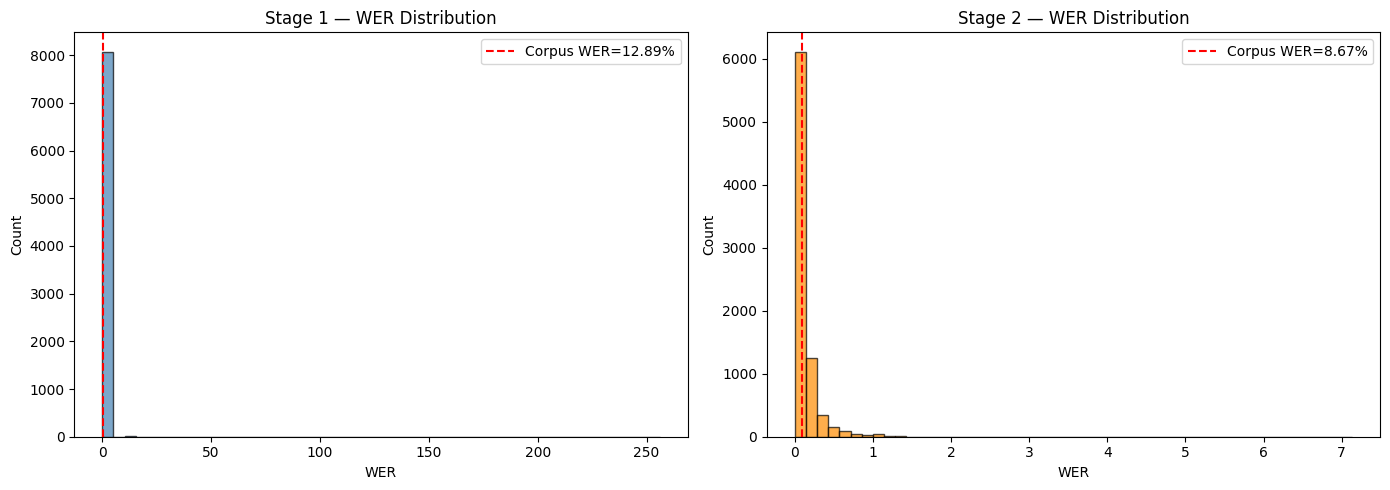

Saved WER distribution plot to ./checkpoints/wer_distribution.png


In [11]:
# WER distribution histogram
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

wers_s1 = [r["wer"] for r in results_s1 if r["wer"] != float("inf")]
wers_s2 = [r["wer"] for r in results_s2 if r["wer"] != float("inf")]

axes[0].hist(wers_s1, bins=50, alpha=0.7, color="steelblue", edgecolor="black")
axes[0].set_title("Stage 1 — WER Distribution")
axes[0].set_xlabel("WER")
axes[0].set_ylabel("Count")
axes[0].axvline(summary_s1["corpus_wer"], color="red", linestyle="--", label=f"Corpus WER={summary_s1['corpus_wer']:.2%}")
axes[0].legend()

axes[1].hist(wers_s2, bins=50, alpha=0.7, color="darkorange", edgecolor="black")
axes[1].set_title("Stage 2 — WER Distribution")
axes[1].set_xlabel("WER")
axes[1].set_ylabel("Count")
axes[1].axvline(summary_s2["corpus_wer"], color="red", linestyle="--", label=f"Corpus WER={summary_s2['corpus_wer']:.2%}")
axes[1].legend()

plt.tight_layout()
plt.savefig("./checkpoints/wer_distribution.png", dpi=150)
plt.show()
print("Saved WER distribution plot to ./checkpoints/wer_distribution.png")

### WER Distribution Analysis                                                                                     
                                                                                                                
The histograms confirm Stage 2 is substantially better across the board, with a small pathological tail:          
                
| Metric | Stage 1 | Stage 2 |
|--------|---------|---------|
| Exact-match rate (WER=0%) | 35.1% | 45.6% |
| Median WER | 7.7% | 4.0% |
| Samples with WER > 100% | 72 | 34 |
| Samples hitting 256-token cap | 14 | 3 |

The bulk of the distribution shifted left (lower WER) after LoRA fine-tuning. The long tail of WER > 100% samples
halved, and the hard cap-hit loops (the worst autoregressive failures) dropped from 14 to 3. This is a good model
with a few ugly tail failures — not a systemic issue.

## 8. Breakdown by Duration

Compute WER/CER per duration bucket to see if the model struggles with
short or long audio.

In [12]:
import pandas as pd

df_s2 = pd.DataFrame(results_s2)

# Buckets: 0-5s, 5-10s, 10-15s, 15-20s, 20-30s, 30s+
bins = [0, 5, 10, 15, 20, 30, float("inf")]
labels = ["0-5s", "5-10s", "10-15s", "15-20s", "20-30s", "30s+"]
df_s2["duration_bucket"] = pd.cut(df_s2["duration"], bins=bins, labels=labels, right=False)

print("=== Stage 2 WER/CER by Duration Bucket ===\n")
print(f"{'Bucket':<10} {'N':>6} {'WER':>10} {'CER':>10}")
print("-" * 38)

for bucket in labels:
    group = df_s2[df_s2["duration_bucket"] == bucket]
    if len(group) == 0:
        continue
    bucket_wer = wer(group["reference"].tolist(), group["prediction"].tolist())
    bucket_cer = cer(group["reference"].tolist(), group["prediction"].tolist())
    print(f"{bucket:<10} {len(group):>6} {bucket_wer:>9.2%} {bucket_cer:>9.2%}")

=== Stage 2 WER/CER by Duration Bucket ===

Bucket          N        WER        CER
--------------------------------------
0-5s         2794     9.40%     5.09%
5-10s        3587     8.60%     4.43%
10-15s       1107     8.06%     4.67%
15-20s        399     7.13%     3.96%
20-30s        182     9.30%     5.08%
30s+           18    23.95%    18.59%


## 9. Custom Audio Inference

Transcribe your own `.wav` files. Supports any sample rate (resampled to 16kHz).

In [13]:
import torchaudio
import torchaudio.transforms as T
from io import BytesIO

def transcribe_audio_file(model, processor, audio_path, target_sr=16000):
    """Load a .wav file, resample to 16kHz, and transcribe."""
    waveform, sr = torchaudio.load(audio_path)

    # Resample if needed
    if sr != target_sr:
        resampler = T.Resample(orig_freq=sr, new_freq=target_sr)
        waveform = resampler(waveform)

    # Stereo to mono
    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)

    # Convert to WAV bytes for process_vision_info
    buffer = BytesIO()
    torchaudio.save(buffer, waveform, target_sr, format="wav")
    audio_bytes = buffer.getvalue()

    messages = [
        {"role": "user", "content": [
            {"type": "audio", "audio": audio_bytes},
            {"type": "text", "text": "Transcribe this audio."},
        ]},
    ]
    return run_inference(model, processor, messages)

print("transcribe_audio_file() defined.")

transcribe_audio_file() defined.


In [14]:
# Uncomment and set your audio file path:
# result = transcribe_audio_file(model_s1, processor, "/path/to/your/audio.wav")
# print(f"Transcription: {result}")

## 10. Cleanup

In [15]:
for name in ["model_s1", "model", "base_model"]:
    if name in dir():
        exec(f"del {name}")
gc.collect()
torch.cuda.empty_cache()
print("Evaluation complete. Cleanup done.")

Evaluation complete. Cleanup done.


In [19]:
# Quick test: re-run the 10 worst samples with repetition_penalty=1.2
# Compare old (greedy) vs new (with penalty) predictions.

# Load Stage 2 model if not already in memory
try:
    model
except NameError:
    print("Loading Stage 2 model...")
    base_model = Qwen2VLForConditionalGeneration.from_pretrained(
        STAGE1_REPO, torch_dtype=torch.bfloat16, device_map=DEVICE,
    )
    base_model.config.use_cache = True
    model = PeftModel.from_pretrained(base_model, LORA_REPO)
    model.eval()
    processor = Qwen2VLProcessor.from_pretrained(STAGE1_REPO)
    print(f"Loaded. GPU memory: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")

# The 10 worst sample indices (from sorted_results)
worst_indices = [r["index"] for r in sorted(results_s2, key=lambda x: x["wer"], reverse=True)[:10]]

print("=" * 80)
print(f"Testing repetition_penalty=1.2 on {len(worst_indices)} worst samples")
print("=" * 80)

for idx in worst_indices:
    sample = test_dataset[idx]
    messages = [
        {"role": "user", "content": [
            {"type": "audio", "audio": sample["wav"]["bytes"]},
            {"type": "text", "text": "Transcribe this audio."},
        ]},
    ]

    # Run with repetition_penalty
    image_inputs, video_inputs, audio_inputs = process_vision_info(messages)
    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    batch = processor(text=[text], audios=audio_inputs, return_tensors="pt", padding=True)
    batch = {k: v.to(model.device) if isinstance(v, torch.Tensor) else v for k, v in batch.items()}
    with torch.inference_mode():
        output_ids = model.generate(
            **batch, max_new_tokens=256, num_beams=1, do_sample=False,
            repetition_penalty=1.2,
        )
    prompt_len = batch["input_ids"].shape[1]
    new_pred = processor.batch_decode(output_ids[:, prompt_len:], skip_special_tokens=True)[0]

    # Look up old prediction
    old_entry = next(r for r in results_s2 if r["index"] == idx)
    old_pred = old_entry.get("prediction_raw", old_entry["prediction"])
    ref = old_entry.get("reference_raw", old_entry["reference"])

    new_wer = wer(normalize_text(ref), normalize_text(new_pred)) if normalize_text(ref) else float("inf")

    print(f"\nSample {idx} (duration={old_entry['duration']:.1f}s)")                                              
    print(f"  REF:     {ref}")
    print(f"  OLD HYP: {old_pred}")                                                                               
    print(f"  NEW HYP: {new_pred}")                                                                             
    print(f"  WER:     {old_entry['wer']:.0%} → {new_wer:.0%}")

Testing repetition_penalty=1.2 on 10 worst samples

Sample 414 (duration=21.4s)
  REF:     LIFE BEFORE DEATH STRENGTH BEFORE WEAKNESS READING BEFORE FINDING OUT HI JJ HI JJ HI JJ YOU KNOW ITS VERY COOL JJ THANK YOU FOR SHOWING ME THERE'S MY CHILD
  OLD HYP: LIFE BEFORE DEATH STRENGTH BEFORE WEAKNESS READING BEFORE FINDING OUT HI JAY JAY HI JAY JAY HI JAY JAY IT WAS VERY COOL JAY JAY THANK YOU FOR SHOWING ME THERE'S MY CHILD AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH AH

### Error Analysis
                                                                                                                
**Failure categories** from the 10 worst Stage 2 predictions:                                                   

1. **Repetition loops** (Samples 414, 7512): Model transcribes correctly but fails to emit `<|im_end|>`, getting
stuck in a loop. Root cause is train/inference mismatch (exposure bias) — during training the model sees correct
previous tokens, but at inference it conditions on its own outputs. Only 3/8,087 Stage 2 predictions hit the
256-token cap (vs 14/8,087 in Stage 1).

2. **Incomplete references** (Samples 8025, 6376, 540, 4216, 2352): The model transcribes *more* speech than the
reference captures. On manual listening, the audio genuinely contains repeated or additional speech — the model is
more correct than the ground truth. These are dataset quality issues, not model failures.

3. **Non-English audio** (Samples 4317, 5216): French/German audio mislabeled as English. Out-of-distribution for
our English-trained model.

4. **Word boundary differences** (Sample 3228): "GREENHORNS" → "GREEN HORNS" — semantically identical, WER metric
artifact.

**Decoding fix tested**: `repetition_penalty=1.2` eliminated the loop in Sample 414 (713% → 40% WER) and helped
Sample 7512 (513% → 97%). Non-repetition samples were unaffected. For production use, `repetition_penalty=1.1` +
`num_beams=2` is the recommended decoding configuration. See `Documentation/Lessons/session7_QA.md` for full
analysis.